# Problem 1

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

In [2]:
# 1a
rng = np.random.default_rng(seed=598)

n = 1000
p = 20

beta = np.array([2, -1, 0, 0.8, 0, -1.5, 1.2, 0, 0, 0.3, -0.7, 0, 1.8, 0, 0.5, 0, -1.2, 0, 0.4, 0])
X = rng.standard_normal(size=(n,  p))
epsilon = rng.standard_normal(n)
Y = (X @ beta) + epsilon

print(beta.shape)
print(X.shape)
print(epsilon.shape)
print(Y.shape)

# 1b
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.8, 
    random_state=598,
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(20,)
(1000, 20)
(1000,)
(1000,)
(200, 20)
(200,)
(800, 20)
(800,)


In [3]:
# 1c
pipes = {
    'train_mse': [],
    'test_mse': [],
    'pipeline': [],
    'model_size': [],
}
model_sizes = range(1, X_train.shape[1] + 1)

for k in model_sizes:
    pipes['model_size'].append(k)

    if k == X_train.shape[1]:
        best_model_pipeline = Pipeline([
            ('regressor', LinearRegression())
        ])
    else:
        best_model_pipeline = Pipeline([
            ('sfs', SequentialFeatureSelector(
                estimator=LinearRegression(), 
                n_features_to_select=k, 
                direction='forward'
            )),
            ('regressor', LinearRegression())
        ])

    best_model_pipeline.fit(X_train, y_train)
    pipes['pipeline'].append(best_model_pipeline)

    y_train_pred = best_model_pipeline.predict(X_train)
    train_mse = mean_squared_error(y_train, y_train_pred)
    pipes['train_mse'].append(train_mse)

    y_test_pred = best_model_pipeline.predict(X_test)
    test_mse = mean_squared_error(y_test, y_test_pred)
    pipes['test_mse'].append(test_mse)

Model size 11 with MSE 1.095 is the minimum MSE on the test set.


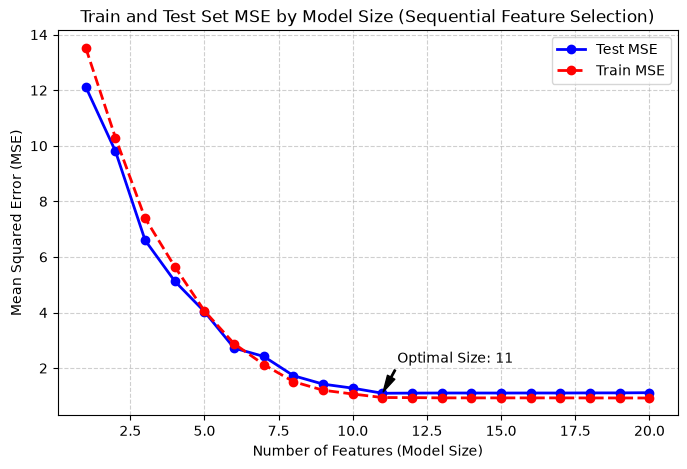

In [4]:
# 1d
plt.figure(figsize=(8, 5))
plt.plot(model_sizes, pipes['test_mse'], marker='o', linestyle='-', color='b', linewidth=2, label='Test MSE')
plt.plot(model_sizes, pipes['train_mse'], marker='o', linestyle='--', color='r', linewidth=2, label='Train MSE')

plt.title('Train and Test Set MSE by Model Size (Sequential Feature Selection)')
plt.xlabel('Number of Features (Model Size)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 1e
# Highlight the optimal model size (lowest test MSE)
best_size = model_sizes[np.argmin(pipes['test_mse'])]
best_mse = min(pipes['test_mse'])
print(f'Model size {best_size} with MSE {best_mse:.4} is the minimum MSE on the test set.')
plt.annotate(f'Optimal Size: {best_size}', 
             xy=(best_size, best_mse), 
             xytext=(best_size + 0.5, best_mse + (max(pipes['test_mse'])-min(pipes['test_mse']))*0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.show()

In [5]:
# 1f
best_pipeline: Pipeline = pipes['pipeline'][np.argmin(pipes['test_mse'])]
lr: LinearRegression = best_pipeline.named_steps['regressor']
sfs: SequentialFeatureSelector = best_pipeline.named_steps['sfs']

selected_mask = sfs.get_support()

beta_hat = np.zeros_like(beta, dtype=float)
beta_hat[selected_mask] = lr.coef_

compare = {
    'true': beta,
    'estimated': beta_hat,
    'selected': selected_mask
}
comp_df = pd.DataFrame(compare, index=[f'X_{i}' for i in range(len(beta))])

print(comp_df)
lr

      true  estimated  selected
X_0    2.0   2.010178      True
X_1   -1.0  -1.168573      True
X_2    0.0   0.000000     False
X_3    0.8   0.849230      True
X_4    0.0   0.000000     False
X_5   -1.5  -1.466732      True
X_6    1.2   1.234496      True
X_7    0.0   0.000000     False
X_8    0.0   0.000000     False
X_9    0.3   0.370593      True
X_10  -0.7  -0.838337      True
X_11   0.0   0.000000     False
X_12   1.8   1.872613      True
X_13   0.0   0.000000     False
X_14   0.5   0.539317      True
X_15   0.0   0.000000     False
X_16  -1.2  -1.312011      True
X_17   0.0   0.000000     False
X_18   0.4   0.347653      True
X_19   0.0   0.000000     False


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 2.01,-1.17, 0.85,..., 0.54,-1.31, 0.35]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.06409
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[17.17,16.57,15.61,...,12.84,11.95,11.76]"


It's clear to me now that the best subset selection I performed removed all the zero value coefficients. This makes sense because the dot product of a matrix and a vector looks like this:

$$
\begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} ax + by \\ cx + dy \end{bmatrix}
$$

A zero would impact it like so:

$$
y=0\\
\begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ 0 \end{bmatrix} = \begin{bmatrix} ax \\ cx \end{bmatrix}
$$

The coefficient does not add to the model in any way.

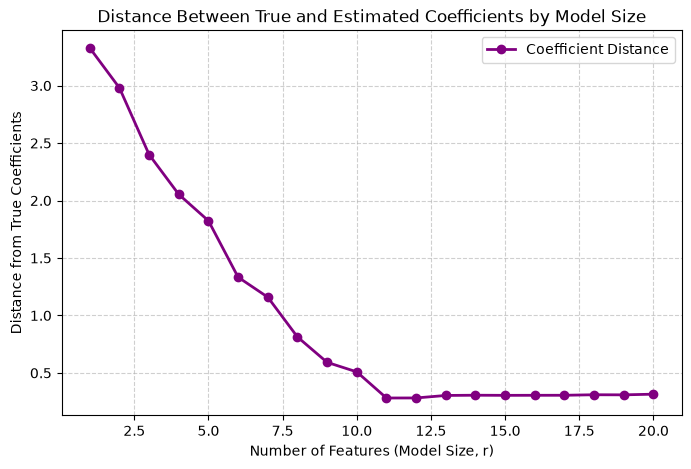

In [6]:
# 1g
def coef_distance(beta, beta_hat):
    return np.sqrt(np.sum((beta - beta_hat) ** 2))

pipes['co_est'] = []
for i in range(len(pipes['pipeline'])):

    pipe = pipes['pipeline'][i]
    lr: LinearRegression = pipe.named_steps['regressor']

    if i != X_train.shape[1] - 1:
        sfs: SequentialFeatureSelector = pipe.named_steps['sfs']
        selected_mask = sfs.get_support()
        beta_hat = np.zeros_like(beta, dtype=float)
        beta_hat[selected_mask] = lr.coef_
    else:
        beta_hat = lr.coef_

    pipes['co_est'].append(coef_distance(beta, beta_hat))

plt.figure(figsize=(8, 5))
plt.plot(model_sizes, pipes['co_est'], marker='o', linestyle='-', color='purple', linewidth=2,label='Coefficient Distance')

plt.title('Distance Between True and Estimated Coefficients by Model Size')
plt.xlabel('Number of Features (Model Size, r)')
plt.ylabel('Distance from True Coefficients')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

The distance of the modeled coefficients to the true coefficients starts high and steadly decreases as the number of features approaches what I have found to be the best number of features for this model (11). After we reach the best number of features the distance slightly rebounds, but it's minimal. This is because of how the matrix-vector dot product works which I explained earlier. Before 11 features the model is missing information and cannot successfully create an accurate model. After 11 features the model has extra coefficients so the information is captured but the extra coefficients slightly perturb the distance and results.

The test MSE plot looks very similar to this one. That is because if the coefficients, or unknowns we are solving for are exactly the same as the true coefficients then the predictions will be as close to matching as possible. Therefore a distance measure of the coefficients being approximately zero would also give us a MSE of approximately zero. The magnitudes are different because MSE takes an average and the distance function takes a square root.

# Problem 2

In [7]:
from ucimlrepo import fetch_ucirepo
import math

In [8]:
# fetch dataset
parkinsons_telemonitoring = fetch_ucirepo(id=189)

# data (as pandas dataframes)
X = parkinsons_telemonitoring.data.features
y = parkinsons_telemonitoring.data.targets

# metadata 
print(parkinsons_telemonitoring.metadata)

# variable information
print(parkinsons_telemonitoring.variables)

y = y.drop(columns=['motor_UPDRS'])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3, 
    random_state=598,
)

y_train = y_train.squeeze()
y_test = y_test.squeeze()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

{'uci_id': 189, 'name': 'Parkinsons Telemonitoring', 'repository_url': 'https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring', 'data_url': 'https://archive.ics.uci.edu/static/public/189/data.csv', 'abstract': "Oxford Parkinson's Disease Telemonitoring Dataset", 'area': 'Health and Medicine', 'tasks': ['Regression'], 'characteristics': ['Tabular'], 'num_instances': 5875, 'num_features': 19, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['motor_UPDRS', 'total_UPDRS'], 'index_col': ['subject#'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5ZS3N', 'creators': ['Athanasios Tsanas', 'Max Little'], 'intro_paper': {'ID': 229, 'type': 'NATIVE', 'title': "Accurate Telemonitoring of Parkinson's Disease Progression by Noninvasive Speech Tests", 'authors': 'A. Tsanas, Max A. Little, P. McSharry, L. Ramig', 'venue': 'IEEE Transactions on Bio

In [15]:
# 2a
pipes = {
    'train_mse': [],
    'test_mse': [],
    'pipeline': [],
    'model_size': [],
    'aic': [],
    'bic': [],
    'r2': [],
    'cp': [],
    'coefs': [],
}
N, M = X_train.shape
model_sizes = range(1, 9)
print(model_sizes)

full_model = LinearRegression().fit(X_train, y_train)
y_pred_full = full_model.predict(X_train)
y_avg = np.sum(y_train) / N
tss_full = np.sum((y_train - y_avg) ** 2)
mse_full = mean_squared_error(y_train, y_pred_full)
rss_full = np.sum((y_train - y_pred_full) ** 2)
sigma2_hat = rss_full / (N - M)

for k in model_sizes:
    best_model_pipeline = Pipeline([
        ('sfs', SequentialFeatureSelector(
            estimator=LinearRegression(), 
            n_features_to_select=k, 
            direction='forward'
        )),
        ('regressor', LinearRegression())
    ])

    best_model_pipeline.fit(X_train, y_train)
    
    y_train_pred = best_model_pipeline.predict(X_train)
    train_mse = mean_squared_error(y_train, y_train_pred)
    y_test_pred = best_model_pipeline.predict(X_test)
    test_mse = mean_squared_error(y_test, y_test_pred)

    log_likelihood = -(N / 2) * (math.log(2 * math.pi) + math.log(train_mse) + 1)
    p = k + 1
    aic = 2 * p - 2 * log_likelihood
    bic = math.log(N) * p - 2 * log_likelihood
    rss = np.sum((y_train - y_train_pred) ** 2)
    r2 = 1 - (rss / (N - p)) / ((tss_full) / (N - 1))
    cp = (rss / sigma2_hat) - N + 2 * p
    
    pipes['train_mse'].append(train_mse)
    pipes['test_mse'].append(test_mse)
    pipes['pipeline'].append(best_model_pipeline)
    pipes['model_size'].append(k)
    pipes['aic'].append(aic)
    pipes['bic'].append(bic)
    pipes['r2'].append(r2)
    pipes['cp'].append(cp)

    print(f'Model size: {k}, train mse: {train_mse}, test mse: {test_mse}, aic: {aic}, bic: {bic}, r2: {r2}, Cp: {cp}')

range(1, 9)
Model size: 1, train mse: 101.2319847635533, test mse: 108.67337172014066, aic: 30660.159997984734, bic: 30672.803327599006, r2: 0.09454474320660222, Cp: 333.9453508464776
Model size: 2, train mse: 99.17069173639733, test mse: 107.01184520386897, aic: 30577.566957540956, bic: 30596.53195196236, r2: 0.11276581685286025, Cp: 245.4981369536199
Model size: 3, train mse: 97.3324058295774, test mse: 104.7757613154166, aic: 30502.629216955134, bic: 30527.915876183673, r2: 0.12900013457232207, Cp: 166.83622405723963
Model size: 4, train mse: 95.97636865941816, test mse: 103.67306427184784, aic: 30446.937926699673, bic: 30478.546250735348, r2: 0.14092580117045206, Cp: 109.33484198286078
Model size: 5, train mse: 94.90695033020255, test mse: 102.00424768329168, aic: 30402.862720102774, bic: 30440.792708945584, r2: 0.1502911572956177, Cp: 64.40997148205497
Model size: 6, train mse: 94.40537269884129, test mse: 100.85206067362543, aic: 30383.073414333438, bic: 30427.325067983384, r2: 0

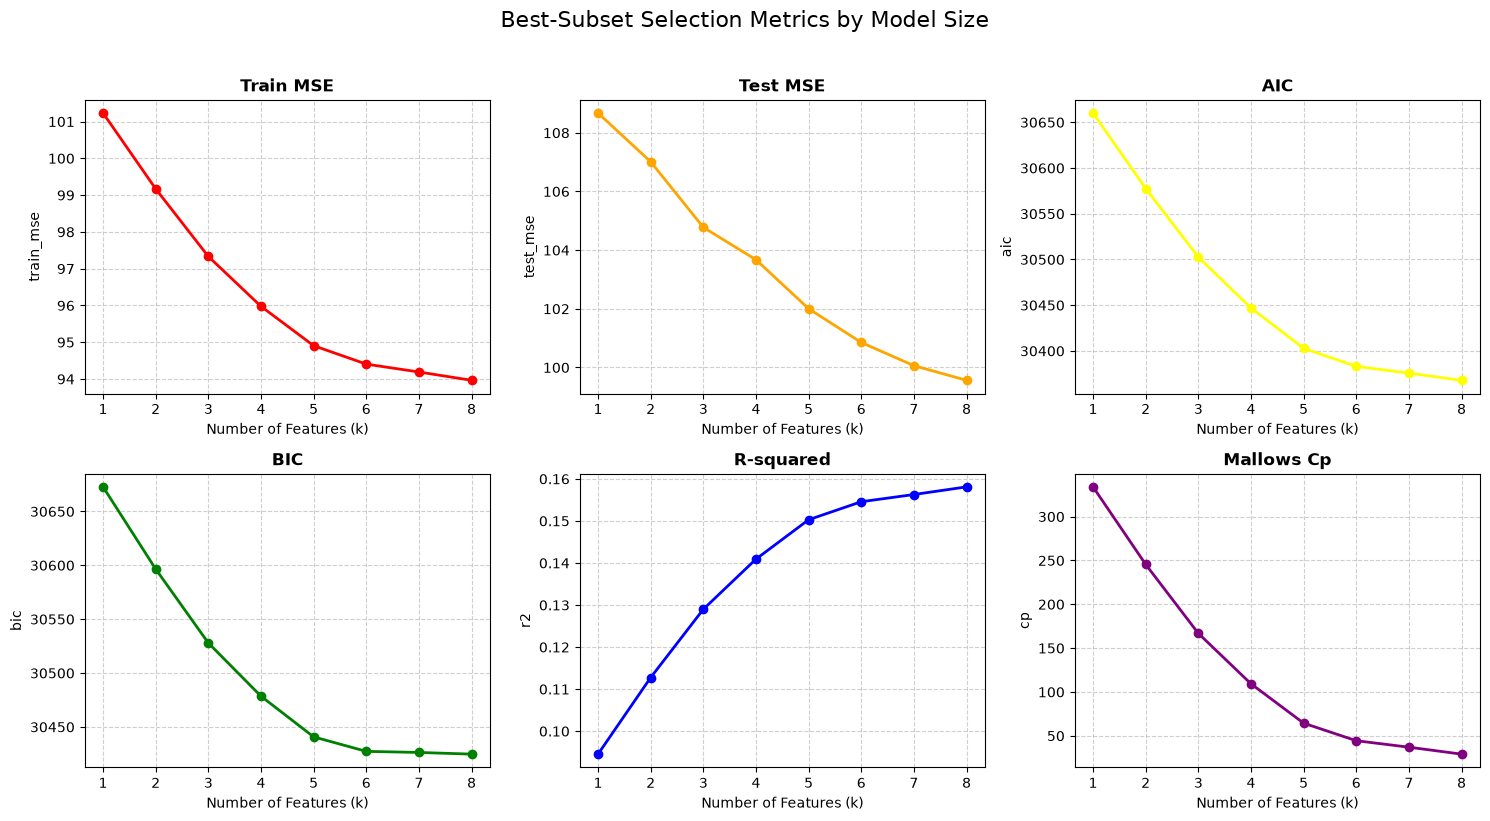

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
fig.suptitle('Best-Subset Selection Metrics by Model Size', fontsize=16, y=1.02)

# Flatten the 2D axes array for easy iteration
axes = axes.flatten()

# Define the data mapping based on your original colors
plots_config = [
    ('train_mse', 'Train MSE', 'red'),
    ('test_mse', 'Test MSE', 'orange'),
    ('aic', 'AIC', 'yellow'), # Note: yellow can be hard to see on white backgrounds
    ('bic', 'BIC', 'green'),
    ('r2', 'R-squared', 'blue'),
    ('cp', 'Mallows Cp', 'purple')
]

for i, (metric, title, color) in enumerate(plots_config):
    axes[i].plot(model_sizes, pipes[metric], marker='o', linestyle='-', color=color, linewidth=2)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Number of Features (k)')
    axes[i].set_ylabel(metric)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # Force integer ticks on the x-axis for model size
    axes[i].set_xticks(model_sizes)

# Automatically adjust spacing between subplots to prevent overlap
plt.tight_layout()
plt.show()

In [17]:
# 2b
best_aic = np.argmin(pipes['aic'])
best_bic = np.argmin(pipes['bic'])
best_r2 = np.argmax(pipes['r2'])
best_cp = np.argmin(pipes['cp'])

print(f'Best AIC model: {pipes['model_size'][best_aic]}, train mse: {pipes['train_mse'][best_aic]}, test mse: {pipes['test_mse'][best_aic]}')
print(f'Best BIC model: {pipes['model_size'][best_bic]}, train mse: {pipes['train_mse'][best_bic]}, test mse: {pipes['test_mse'][best_bic]}')
print(f'Best R2 model: {pipes['model_size'][best_r2]}, train mse: {pipes['train_mse'][best_r2]}, test mse: {pipes['test_mse'][best_r2]}')
print(f'Best Mallows Cp model: {pipes['model_size'][best_cp]}, train mse: {pipes['train_mse'][best_cp]}, test mse: {pipes['test_mse'][best_cp]}')

Best AIC model: 8, train mse: 93.96541962485, test mse: 99.56328020829059
Best BIC model: 8, train mse: 93.96541962485, test mse: 99.56328020829059
Best R2 model: 8, train mse: 93.96541962485, test mse: 99.56328020829059
Best Mallows Cp model: 8, train mse: 93.96541962485, test mse: 99.56328020829059


In [35]:
# 2c
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

rcv = RidgeCV(alphas=np.logspace(-2, 3, 100), store_cv_results=True).fit(X_train_scaled, y_train)
rcv.alpha_

68.92612104349695

In [36]:
# 2d
lcv = LassoCV().fit(X_train_scaled, y_train)
mask = lcv.coef_ == 0
print(f'Coefficients identified as zero: {X_train.columns[mask]}')

Coefficients identified as zero: Index(['Jitter(%)', 'Shimmer'], dtype='str')


/Users/davidgray/git/cs598-psl/CS598-PSL-MP2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.058431e+01, tolerance: 3.684e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/davidgray/git/cs598-psl/CS598-PSL-MP2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.534068e+01, tolerance: 3.684e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Users/davidgray/git/cs598-psl/CS598-PSL-MP2/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase th

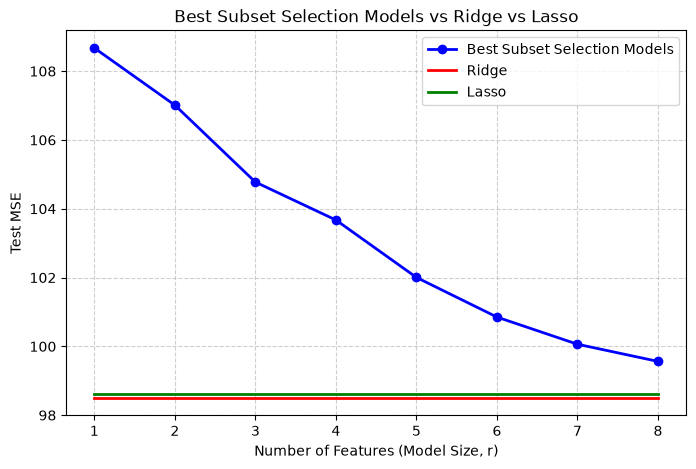

In [37]:
X_test_scaled = scaler.transform(X_test)
ridge_preds = rcv.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_preds)
lasso_preds = lcv.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_preds)

plt.figure(figsize=(8, 5))
plt.plot(model_sizes, pipes['test_mse'], marker='o', linestyle='-', color='b', linewidth=2, label='Best Subset Selection Models')
plt.plot(model_sizes, [ridge_mse for i in model_sizes], linestyle='-', color='r', linewidth=2, label='Ridge')
plt.plot(model_sizes, [lasso_mse for i in model_sizes], linestyle='-', color='g', linewidth=2, label='Lasso')

plt.title('Best Subset Selection Models vs Ridge vs Lasso')
plt.xlabel('Number of Features (Model Size, r)')
plt.ylabel('Test MSE')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()